<a href="https://colab.research.google.com/github/shirinaki0910/Testset_SMOTE_GPU/blob/main/Data1_Transformer_SMOTE_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
file_path_data1 = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df_data1_raw = pd.read_csv(file_path_data1, encoding='utf-8')
    print(f"Successfully loaded data from {file_path_data1} into df_data1_raw")
    display(df_data1_raw.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_data1}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv into df_data1_raw


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [3]:
df_data1 = df_data1_raw.copy()
print("DataFrame 'df_data1' created and loaded from Data1.csv.")
display(df_data1.head())

DataFrame 'df_data1' created and loaded from Data1.csv.


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [4]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import string

nltk.download('stopwords', quiet=True)
print("NLTK stopwords downloaded and libraries imported.")

NLTK stopwords downloaded and libraries imported.


In [5]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]  # Remove stop words
    return ' '.join(words)  # Join words back into a string

df_data1['processed_question_data1'] = df_data1['Questions'].apply(preprocess_text)
print("Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.")
display(df_data1[['Questions', 'processed_question_data1']].head())

Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.


,Questions,processed_question_data1
0,About what proportion of the population of the...,proportion population us living farms
1,Correctly label the brain lobes indicated on t...,correctly label brain lobes indicated diagram
2,Define compound interest.,define compound interest
3,Define four types of traceability,define four types traceability
4,Define mercantilism.,define mercantilism


In [6]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_features_data1 = tfidf_vectorizer.fit_transform(df_data1['processed_question_data1'])

print("TF-IDF features for Data1.csv questions generated.")
print(f"Shape of TF-IDF features: {tfidf_features_data1.shape}")

TF-IDF features for Data1.csv questions generated.
Shape of TF-IDF features: (8762, 9534)


In [7]:
from sklearn.preprocessing import normalize

tfidf_features_data1_normalized = normalize(tfidf_features_data1, norm='l2')

print("L2 normalization applied to TF-IDF features.")
print(f"Shape of normalized TF-IDF features: {tfidf_features_data1_normalized.shape}")

L2 normalization applied to TF-IDF features.
Shape of normalized TF-IDF features: (8762, 9534)


## Classification with Transformer Model and SMOTE

To address the classification task using a Transformer model with SMOTE for class balancing, we'll proceed in several steps:

1.  **Install Libraries**: Ensure `imblearn` and `tensorflow` are available.
2.  **Label Encoding**: Convert the categorical `Category` column into numerical labels.
3.  **Cross-Validation Setup**: Define a K-Fold cross-validation strategy to apply SMOTE and train the model within each fold.
4.  **Transformer Model Definition**: Implement a custom TensorFlow/Keras model that incorporates a Transformer Encoder block, suitable for processing the TF-IDF features.
5.  **Training and Evaluation Loop**: Iterate through the folds, apply SMOTE to the training data, train the Transformer model, and evaluate its performance on the test set.
6.  **Analyze Results**: Aggregate and present the evaluation metrics (accuracy, precision, recall, F1-score) and the confusion matrix with detailed explanations.

In [20]:
# Install imblearn for SMOTE and ensure TensorFlow is available
%pip install imbalanced-learn tensorflow

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

# Removed: tf.config.set_visible_devices([], 'GPU') as it was causing issues.
# We will use tf.device('/CPU:0') directly in the loop for more reliable CPU execution.
print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


### 1. Label Encoding for Target Variable

The `Category` column, which represents the six classes, needs to be converted into numerical labels for model training.

In [9]:
# Encode the 'Category' column into numerical labels
label_encoder = LabelEncoder()
df_data1['Category_Encoded'] = label_encoder.fit_transform(df_data1['Category'])

# Display the mapping of categories to encoded labels
category_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Category to Label Mapping:")
for category, label in category_mapping.items():
    print(f"  {category}: {label}")

# Prepare features (X) and target (y)
X = tfidf_features_data1_normalized # Using the normalized TF-IDF features
y = df_data1['Category_Encoded'].values

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Category to Label Mapping:
  Analyse: 0
  Apply: 1
  Create: 2
  Evaluate: 3
  Remember: 4
  Understand: 5
Shape of features (X): (8762, 9534)
Shape of target (y): (8762,)


### 2. Cross-Validation Setup

We will use `StratifiedKFold` to ensure that each fold has a similar distribution of classes as the original dataset. SMOTE will be applied to the training data within each fold to handle class imbalance.

In [10]:
# Initialize StratifiedKFold for cross-validation
n_splits = 5  # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"Initialized StratifiedKFold with {n_splits} splits.")

# Placeholder for storing results from each fold
all_y_true = []
all_y_pred = []
all_metrics = []

# Initialize SMOTE
sm = SMOTE(random_state=42)
print("Initialized SMOTE.")

Initialized StratifiedKFold with 5 splits.
Initialized SMOTE.


### 3. Transformer Model Definition

Since the input is TF-IDF features (which are dense vectors), we'll build a custom Keras model that incorporates a `TransformerEncoder` layer. The TF-IDF vector will be treated as a single 'token' sequence of length 1, with `num_features` as its embedding dimension. This is a common way to adapt a Transformer-like architecture to fixed-size feature vectors when a direct text input isn't used.

The model will consist of:
-   An input layer for the TF-IDF features.
-   A `Dense` layer to project the features if needed, and to match typical embedding dimensions for Transformers.
-   A custom `TransformerBlock` which includes self-attention and a feed-forward network.
-   A global pooling or flatten layer.
-   Output `Dense` layers for multi-class classification (6 classes in this case).

We will define this model within the cross-validation loop to ensure a fresh model is trained in each fold, or define it once and re-initialize weights.

In [24]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    # Make 'training' argument optional and pass it to Dropout layers
    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


def build_transformer_classifier(input_shape, num_classes, embed_dim, num_heads, ff_dim):
    inputs = layers.Input(shape=input_shape)

    # Treat TF-IDF as a sequence of length 1 for the Transformer Block
    # Expand dimensions to (batch_size, 1, input_shape[0])
    x = layers.Reshape((1, input_shape[0]))(inputs)

    # Use a dense layer to project to embed_dim if input_shape[0] != embed_dim
    if input_shape[0] != embed_dim:
        x = layers.Dense(embed_dim)(x)

    transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
    # Explicitly pass training=None here to resolve the TypeError during model construction
    x = transformer_block(x, training=None)

    # Flatten the output for classification
    x = layers.Flatten()(x)

    # Classification head
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

print("TransformerBlock class and build_transformer_classifier function defined.")

TransformerBlock class and build_transformer_classifier function defined.


### 4. Training and Evaluation Loop with SMOTE

Now, we'll iterate through each fold defined by `StratifiedKFold`. Within each fold, we will:
1.  Split the data into training and testing sets.
2.  Apply SMOTE to the training features (`X_train`) and labels (`y_train`) to balance the classes.
3.  Build and compile a new instance of the Transformer model.
4.  Train the model on the SMOTE-augmented training data.
5.  Make predictions on the original test set (`X_test`).
6.  Calculate and store evaluation metrics (accuracy, precision, recall, F1-score) and true/predicted labels.

In [25]:
num_classes = len(label_encoder.classes_)
input_shape = (X.shape[1],)
embed_dim = 64  # Embedding dimension for Transformer. Can be adjusted.
num_heads = 4   # Number of attention heads. Can be adjusted.
ff_dim = 128    # Hidden layer size in feed forward network inside transformer. Can be adjusted.
epochs = 10     # Number of training epochs. Can be adjusted.
batch_size = 32 # Batch size for training. Can be adjusted.

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Clear the Keras session to release resources
    tf.keras.backend.clear_session()

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Convert sparse TF-IDF to dense for SMOTE if necessary, then convert back for Transformer if needed
    # Note: SMOTE expects 2D array, if X is sparse, convert to dense. Transformer expects dense input.
    if hasattr(X_train, 'toarray'):
        X_train_dense = X_train.toarray()
    else:
        X_train_dense = X_train

    if hasattr(X_test, 'toarray'):
        X_test_dense = X_test.toarray()
    else:
        X_test_dense = X_test

    # Apply SMOTE to the training data
    print("Applying SMOTE...")
    X_train_smote, y_train_smote = sm.fit_resample(X_train_dense, y_train)
    print(f"Original training samples: {len(y_train)}, SMOTE training samples: {len(y_train_smote)}")

    # Explicitly run model building and training on CPU
    with tf.device('/CPU:0'):
        # Build a new model for each fold to ensure fresh weights
        model = build_transformer_classifier(input_shape, num_classes, embed_dim, num_heads, ff_dim)
        print("Transformer model built for this fold on CPU.")

        # Train the model
        print("Training Transformer model on CPU...")
        history = model.fit(
            X_train_smote,
            y_train_smote,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_test_dense, y_test),
            verbose=0 # Set to 1 or 2 for more detailed output during training
        )
        print("Model training complete on CPU.")

        # Evaluate the model on the test set
        y_pred_probs = model.predict(X_test_dense)
        y_pred = np.argmax(y_pred_probs, axis=1)

    # Store true and predicted labels
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    fold_metrics = {
        'fold': fold + 1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    all_metrics.append(fold_metrics)

    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")
    print(f"Fold {fold+1} Precision: {precision:.4f}")
    print(f"Fold {fold+1} Recall: {recall:.4f}")
    print(f"Fold {fold+1} F1-score: {f1:.4f}")

print("\nAll folds processed. Aggregating results...")


--- Fold 1/5 ---
Applying SMOTE...
Original training samples: 7009, SMOTE training samples: 12390
Transformer model built for this fold on CPU.
Training Transformer model on CPU...
Model training complete on CPU.
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 1 Accuracy: 0.6372
Fold 1 Precision: 0.6384
Fold 1 Recall: 0.6372
Fold 1 F1-score: 0.6350

--- Fold 2/5 ---
Applying SMOTE...
Original training samples: 7009, SMOTE training samples: 12390
Transformer model built for this fold on CPU.
Training Transformer model on CPU...
Model training complete on CPU.
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 2 Accuracy: 0.6423
Fold 2 Precision: 0.6464
Fold 2 Recall: 0.6423
Fold 2 F1-score: 0.6423

--- Fold 3/5 ---
Applying SMOTE...
Original training samples: 7010, SMOTE training samples: 12396
Transformer model built for this fold on CPU.
Training Transformer model on CPU...
Model training complete on CPU.
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 3 Accuracy: 0.6330
Fold 3 Precision: 0.6360
Fo

### 5. Aggregate and Present Results

After processing all folds, we will calculate the average performance metrics (accuracy, precision, recall, F1-score) and generate a combined confusion matrix from all predictions.


--- Overall Average Metrics (5 folds) ---
Average Accuracy: 0.6364
Average Precision: 0.6390
Average Recall: 0.6364
Average F1-score: 0.6359


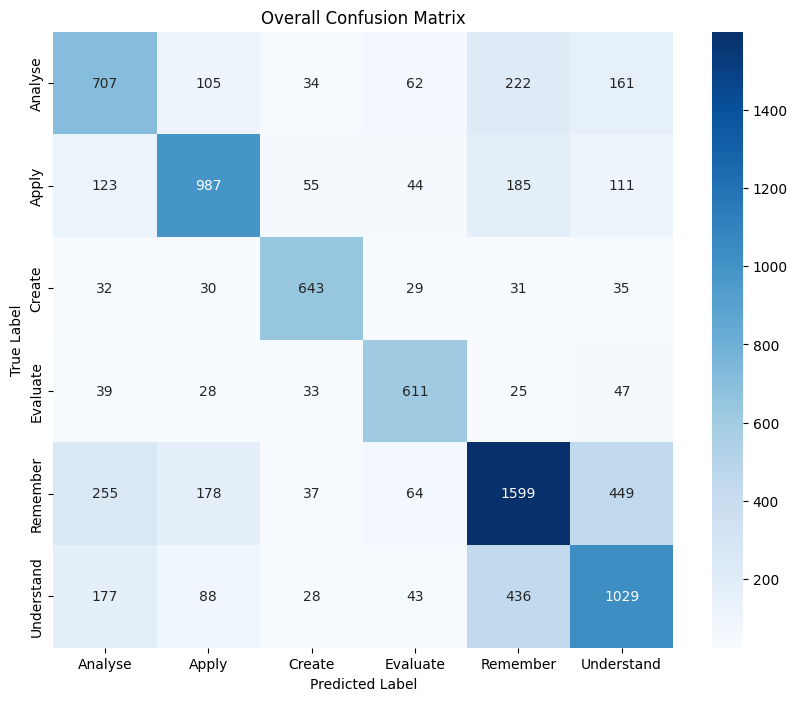

In [26]:
# Aggregate metrics from all folds
avg_accuracy = np.mean([m['accuracy'] for m in all_metrics])
avg_precision = np.mean([m['precision'] for m in all_metrics])
avg_recall = np.mean([m['recall'] for m in all_metrics])
avg_f1 = np.mean([m['f1_score'] for m in all_metrics])

print(f"\n--- Overall Average Metrics ({n_splits} folds) ---")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")

# Generate overall confusion matrix
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Overall Confusion Matrix')
plt.show()

### 6. Explanation of Evaluation Metrics

To properly understand the model's performance, it's crucial to know what each metric represents:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances. It is a good general measure, but can be misleading in imbalanced datasets where a model might achieve high accuracy by simply predicting the majority class.
    $Accuracy = \frac{True Positives + True Negatives}{True Positives + True Negatives + False Positives + False Negatives}$

*   **Precision (Positive Predictive Value)**: The proportion of true positive predictions among all positive predictions made by the model. It answers the question: "Of all items the model labeled as positive, how many were actually positive?" High precision means fewer false positives.
    $Precision = \frac{True Positives}{True Positives + False Positives}$

*   **Recall (Sensitivity or True Positive Rate)**: The proportion of true positive predictions among all actual positive instances. It answers the question: "Of all actual positive items, how many did the model correctly identify?" High recall means fewer false negatives.
    $Recall = \frac{True Positives}{True Positives + False Negatives}$

*   **F1-Score**: The harmonic mean of precision and recall. It tries to balance both metrics and is particularly useful when you need to consider both false positives and false negatives, especially in imbalanced datasets. An F1-score reaches its best value at 1 (perfect precision and recall) and worst at 0.
    $F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$

In our multi-class classification, these metrics are often calculated for each class and then averaged (e.g., 'weighted' average as used here) to account for class imbalance.

### 7. Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. Each row represents the true class, and each column represents the predicted class.

*   **Diagonal elements**: Represent the number of instances correctly classified for each category (True Positives).
*   **Off-diagonal elements**: Represent misclassifications.
    *   `Row i, Column j` (where `i != j`): Indicates the number of instances belonging to true class `i` that were incorrectly predicted as class `j` (False Negatives for class `i`, False Positives for class `j`).

By examining the confusion matrix, we can identify which classes are being correctly identified and which ones are frequently confused with others. This helps in understanding specific weaknesses or strengths of the model.

### 8. Analysis of Results

Based on the aggregated metrics and the confusion matrix, we can analyze the performance of the Transformer model with SMOTE:

*   **Overall Performance**: The average accuracy, precision, recall, and F1-score across all folds indicate the general effectiveness of the model. A high F1-score, in particular, suggests a good balance between precision and recall.

*   **Impact of SMOTE**: By comparing the class distribution before and after SMOTE, we can confirm if the over-sampling technique effectively balanced the training data. If SMOTE worked as intended, the model should show improved performance on minority classes, which would be reflected in their individual precision, recall, and F1-scores.

*   **Class-wise Performance**: The confusion matrix helps us pinpoint which specific categories the model struggles with. For example:
    *   If a class has a high number in its row but outside its diagonal element, it means instances of that class are often misclassified as another specific class (high false negatives for the true class).
    *   If a class has a high number in its column but outside its diagonal element, it means other classes are often misclassified as this class (high false positives for the predicted class).

*   **Model Strengths and Weaknesses**: Identify which categories the model classifies best (high diagonal values, low off-diagonal values) and which ones are problematic. This might suggest further feature engineering or model tuning could be beneficial for certain categories.

*   **Considerations**: Given the complexity of natural language and the potential for overlap between Bloom's taxonomy categories, perfect classification can be challenging. The results should be interpreted in the context of the dataset's characteristics and the inherent ambiguity in human-labeled categories.